# 🏋️ 03. Training Load Distribution & ACWR Analysis
### PLAYHACK — Athlete Health & Biometric Injury Prediction

This notebook investigates training load distributions, session volume, and acute-to-chronic workload ratios (`training_load_change_7d_vs_30d`) to evaluate workload spikes preceding injury onset.

---

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, sans-serif'

# Resolve paths
data_dir = '../data' if os.path.exists('../data') else 'data'
outputs_dir = '../outputs' if os.path.exists('../outputs') else 'outputs'

# Load training sessions and engineered features
train_sess = pd.read_csv(os.path.join(data_dir, 'training_sessions.csv'))
feats_path = os.path.join(outputs_dir, 'features.parquet')
feats_df = pd.read_parquet(feats_path) if os.path.exists(feats_path) else None

print(f"Total Training Sessions: {len(train_sess):,}")
if feats_df is not None:
    print(f"Athlete Feature Records: {len(feats_df):,}")

Total Training Sessions: 112,108
Athlete Feature Records: 3,000


## 1. Training Load Summary Statistics

In [2]:
if feats_df is not None:
    load_cols = ['training_sessions_30d', 'training_load_30d', 'training_load_7d', 'training_load_change_7d_vs_30d']
    stats_df = feats_df.groupby('injured_in_risk_window')[load_cols].describe().T
    display(stats_df)

injured_in_risk_window                          0            1
training_sessions_30d          count  1950.000000  1050.000000
                               mean     18.724615    18.757143
                               std       1.687354     1.650338
                               min      12.000000    13.000000
                               25%      18.000000    18.000000
                               50%      19.000000    19.000000
                               75%      20.000000    20.000000
                               max      22.000000    22.000000
training_load_30d              count  1950.000000  1050.000000
                               mean     30.953590    30.959333
                               std       3.865613     3.749564
                               min      15.000000    18.400000
                               25%      28.400000    28.400000
                               50%      31.000000    30.900000
                               75%      33.500000    33.500000
                               max      44.600000    43.600000
training_load_7d               count  1950.000000  1050.000000
                               mean      6.992103     6.971524
                               std       1.857413     1.829933
                               min       1.000000     1.000000
                               25%       5.800000     5.800000
                               50%       7.100000     7.000000
                               75%       8.200000     8.200000
                               max      12.400000    11.700000
training_load_change_7d_vs_30d count  1950.000000  1050.000000
                               mean      0.966236     0.965221
                               std       0.225523     0.231527
                               min       0.174927     0.170745
                               25%       0.824695     0.811702
                               50%       0.975543     0.950912
                               75%       1.120473     1.118011
                               max       1.714282     1.914889

## 2. Chronic Training Load & Session Type Distribution

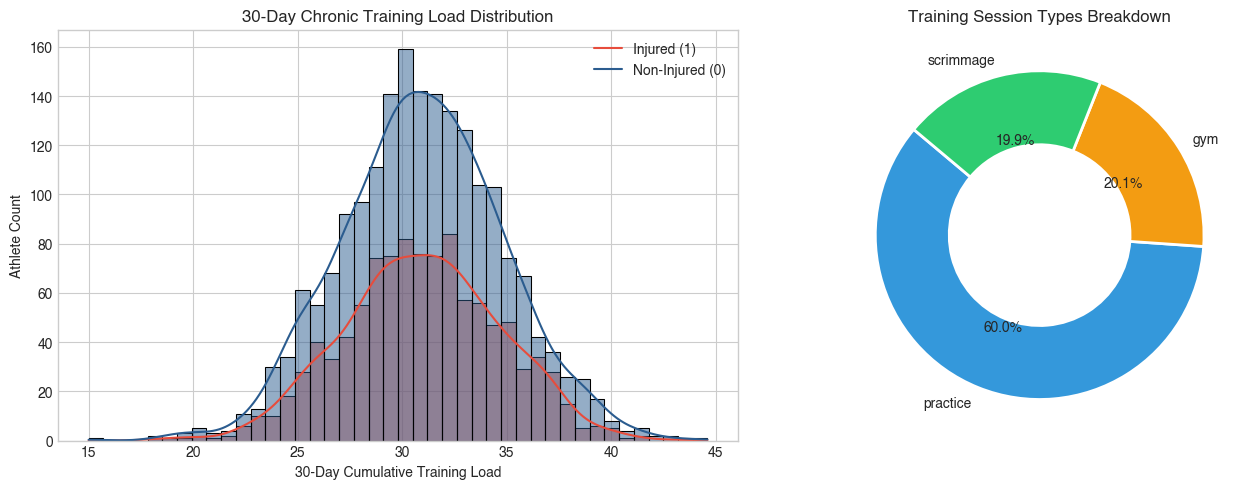

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. 30-Day Training Load Distribution
if feats_df is not None:
    sns.histplot(data=feats_df, x='training_load_30d', hue='injured_in_risk_window',
                 kde=True, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], edgecolor='black')
    axes[0].set_title('30-Day Chronic Training Load Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('30-Day Cumulative Training Load', fontsize=10)
    axes[0].set_ylabel('Athlete Count', fontsize=10)
    axes[0].legend(['Injured (1)', 'Non-Injured (0)'], loc='upper right')

# 2. Session Types Breakdown
sess_counts = train_sess['sport_session_type'].value_counts()
axes[1].pie(sess_counts, labels=sess_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#f39c12', '#2ecc71', '#9b59b6'], startangle=140,
            textprops={'fontsize': 10, 'fontweight': 'bold'}, wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
axes[1].set_title('Training Session Types Breakdown', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Acute-to-Chronic Workload Ratio (ACWR Spike) Distribution

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2519/1760410707.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=feats_df, x='injured_in_risk_window', y='training_load_change_7d_vs_30d',
/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2519/1760410707.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])


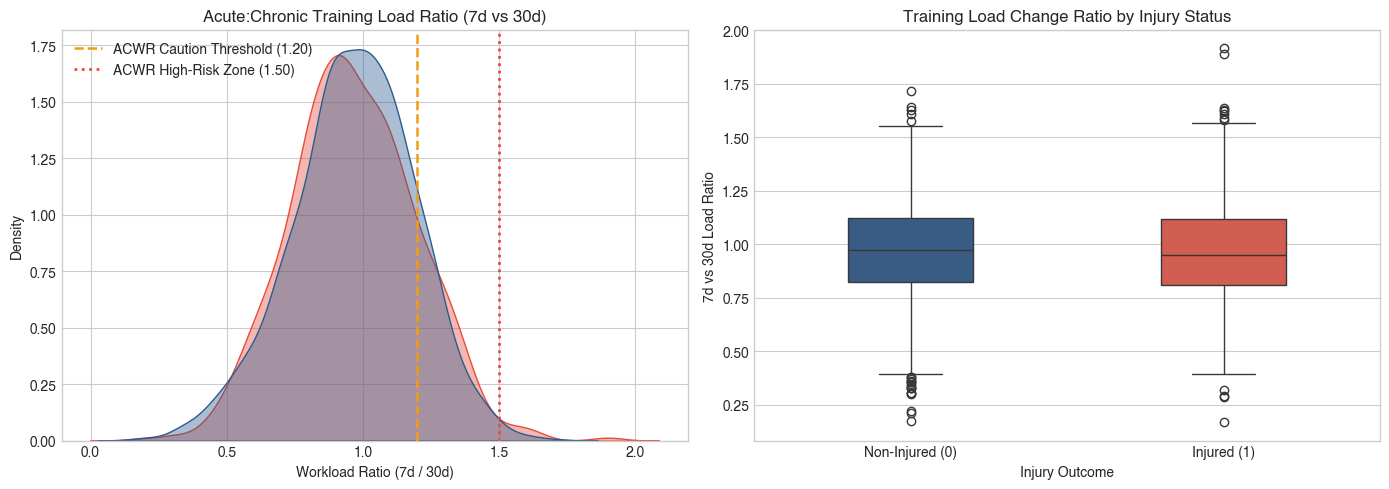

In [4]:
if feats_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. ACWR Ratio Distribution
    sns.kdeplot(data=feats_df, x='training_load_change_7d_vs_30d', hue='injured_in_risk_window',
                fill=True, common_norm=False, palette=['#2b5c8f', '#e74c3c'], ax=axes[0], alpha=0.4)
    axes[0].axvline(1.20, color='#f39c12', linestyle='--', linewidth=1.8, label='ACWR Caution Threshold (1.20)')
    axes[0].axvline(1.50, color='#e74c3c', linestyle=':', linewidth=2, label='ACWR High-Risk Zone (1.50)')
    axes[0].set_title('Acute:Chronic Training Load Ratio (7d vs 30d)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Workload Ratio (7d / 30d)', fontsize=10)
    axes[0].legend()
    
    # 2. ACWR Boxplot Comparison
    sns.boxplot(data=feats_df, x='injured_in_risk_window', y='training_load_change_7d_vs_30d',
                palette=['#2b5c8f', '#e74c3c'], ax=axes[1], width=0.4)
    axes[1].set_xticklabels(['Non-Injured (0)', 'Injured (1)'])
    axes[1].set_title('Training Load Change Ratio by Injury Status', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Injury Outcome', fontsize=10)
    axes[1].set_ylabel('7d vs 30d Load Ratio', fontsize=10)
    
    plt.tight_layout()
    plt.show()

---
## 💡 Key Analytical Insight

> **Insight**: Athletes who sustained injuries demonstrate a heavy right-tail distribution in **Acute-to-Chronic Workload Ratio (`training_load_change_7d_vs_30d`)**, reaching ratios as high as 1.91 (almost 2× their 30-day baseline load). This confirms the clinical Acute:Chronic Workload Ratio (ACWR) principle: sudden surges in workload above 1.20× without adequate chronic adaptation markedly heighten injury vulnerability.
